# Improving earthquake metadata for GNSS time series analysis using Okada-based co-seismic deformation modelling
# ***Point Source Coseismic Slip Plots***
*** 
***

## **0. Point Source Formulae** ##

In [1]:
def coords (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam):
    distance_m, azimuth, baz = gps2dist_azimuth(evlat, evlon, stalat, stalon)
    dEast = distance_m*np.sin(azimuth*np.pi/180.0) #m
    dNorth = distance_m*np.cos(azimuth*np.pi/180.0) #m

    x = dEast * np.sin(strike*np.pi/180.0) + dNorth * np.cos(strike*np.pi/180.0) #m
    y = -dEast * np.cos(strike*np.pi/180.0) + dNorth * np.sin(strike*np.pi/180.0) #m
    d = abs(evdep) #m
    delta = dip*np.pi/180.0 #radians
    
    p = y*np.cos(delta)+d*np.sin(delta) #m
    q = y*np.sin(delta)-d*np.cos(delta) #m

    mu = 10**9*mu #convert GPa to N/m^2
    lam = 10**9*lam #convert GPa to N/m^2
    return(
        m0/mu*np.cos(rake*np.pi/180.0), #m^3 #U1*delsigma
        m0/mu*np.sin(rake*np.pi/180.0), #m^3 #U2*delsigma
        x, #m #x
        y, #m #y
        d, #m #d
        mu, #GPa->N/m^2 #mu
        lam, #GPa->N/m^2 #lam
        delta, #rad #delta
        p, #m #p
        q, #m #q
        np.sqrt(x**2.0+y**2.0+d**2.0), #m #R
        p*np.sin(delta)+q*np.cos(delta) #m #s
    )

In [2]:
def disp_strike (U1, x, y, d, q, R, I1, I2, I4, delta):
    return (
        -U1/(2.0*np.pi)*((3.0*x**2.0*q/R**5.0)+I1*np.sin(delta)), #m
        -U1/(2.0*np.pi)*((3.0*x*y*q/R**5.0)+I2*np.sin(delta)), #m
        -U1/(2.0*np.pi)*((3.0*x*d*q/R**5.0)+I4*np.sin(delta)) #m
    )

In [3]:
def disp_dip (U2, x, y, d, p, q, R, I1, I3, I5, delta):
    return (
        -U2/(2.0*np.pi)*((3.0*x*p*q/R**5.0)-I3*np.sin(delta)*np.cos(delta)), #m
        -U2/(2.0*np.pi)*((3.0*y*p*q/R**5.0)-I1*np.sin(delta)*np.cos(delta)), #m
        -U2/(2.0*np.pi)*((3.0*d*p*q/R**5.0)-I5*np.sin(delta)*np.cos(delta)) #m
    )

In [4]:
def disp_I (x, y, d, R, mu, lam):
    I2=(mu/(lam+mu))*x*((1.0/(R*(R+d)**2.0))-y**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0))
    return(
        (mu/(lam+mu))*y*((1.0/(R*(R+d)**2.0))-x**2.0*(3.0*R+d)/(R**3.0*(R+d)**3.0)),
        I2,
        (mu/(lam+mu))*(x/R**3.0)-I2,
        (mu/(lam+mu))*(-x*y*(2.0*R+d)/(R**3.0*(R+d)**2.0)),
        (mu/(lam+mu))*((1.0/(R*(R+d)))-x**2.0*(2.0*R+d)/(R**3.0*(R+d)**2.0))
    )

In [5]:
def displacement (stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam) :
    U1, U2, x, y, d, mu, lam, delta, p, q, R, s = coords(stalon, stalat, evlon, evlat, evdep, strike, dip, rake, m0, mu, lam)
    I1, I2, I3, I4, I5 = disp_I (x, y, d, R, mu, lam)
    ux_strike, uy_strike, uz_strike = disp_strike (U1, x, y, d, q, R, I1, I2, I4, delta)
    ux_dip, uy_dip, uz_dip = disp_dip (U2, x, y, d, p, q, R, I1, I3, I5, delta)
    ux = ux_strike + ux_dip
    uy = uy_strike + uy_dip
    uz = uz_strike + uz_dip
    return (ux, uy, uz)

In [6]:
def NE_rotate(ux, uy, uz, strike):
    return(
        (ux * np.cos(strike*np.pi/180.0) + uy * np.sin(strike*np.pi/180.0))*10.0**3.0, #mm #dN
        (ux * np.sin(strike*np.pi/180.0) - uy * np.cos(strike*np.pi/180.0))*10.0**3.0, #mm #dE
        uz*10.0**3.0 #mm #dH
    )

## **1. 2020 Samos M6.99 Earthquake Coseismic Deformation Estimate using Finite Source Approximation** ##

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from obspy import read_events
from obspy import UTCDateTime
from obspy.geodetics import gps2dist_azimuth
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

/home/ubuntu_user/miniconda3/envs/OCM_packs/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [8]:
# Catalog Data
big10_catalog = read_events("Big10_Greece_Seismicity.xml")

event = big10_catalog[9]

# Read earthquake data
origin = event.preferred_origin() or event.origins[0]
event_time = origin.time
focal_mech = event.preferred_focal_mechanism() or event.focal_mechanisms[0]
moment_tensor = focal_mech.moment_tensor
nodal_planes = focal_mech.nodal_planes

plane1 = nodal_planes.nodal_plane_1

# Declare variables
evlat = origin.latitude #degN
evlon = origin.longitude #degE
evdep = origin.depth #obspy automatically converts km to m

strike1 = plane1.strike #deg
dip1 = plane1.dip #deg
rake1 = plane1.rake #deg

mag = event.preferred_magnitude() or event.magnitudes[0]
mag = float(mag.mag)
m0 = moment_tensor.scalar_moment #obspy automatically converts from dyne-cm to N-m

mu = 30.0 #GPa #mu
lam = 30.0 #GPa #lambda

In [9]:
# Creating Grid
lon_min, lon_max = evlon-1.0, evlon+1.0
lat_min, lat_max = evlat-1.0, evlat+1.0
X = np.arange(lon_min, lon_max, 0.0625)
Y = np.arange(lat_min, lat_max, 0.0625)
X_mesh, Y_mesh = np.meshgrid(X, Y)

Z_dE1 = np.zeros((len(X), len(Y)))
Z_dN1 = np.zeros((len(X), len(Y)))
Z_dH1 = np.zeros((len(X), len(Y)))

In [12]:
for i in range(len(X)):
    for j in range(len(Y)):
        # Nodal plane 1
        ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike1, dip1, rake1, m0, mu, lam)
        dN, dE, dH = NE_rotate(ux, uy, uz, strike1)
        # Computing Z deformation (dH)
        Z_dE1[i,j] = Z_dE1[i,j]+dE
        Z_dN1[i,j] = Z_dN1[i,j]+dN
        Z_dH1[i,j] = Z_dH1[i,j]+dH

Z = np.array((np.max(abs(Z_dE1)), np.max(abs(Z_dN1)), np.max(abs(Z_dH1))))
print(Z)

[1331.6769854  1334.79565008 4289.65854617]


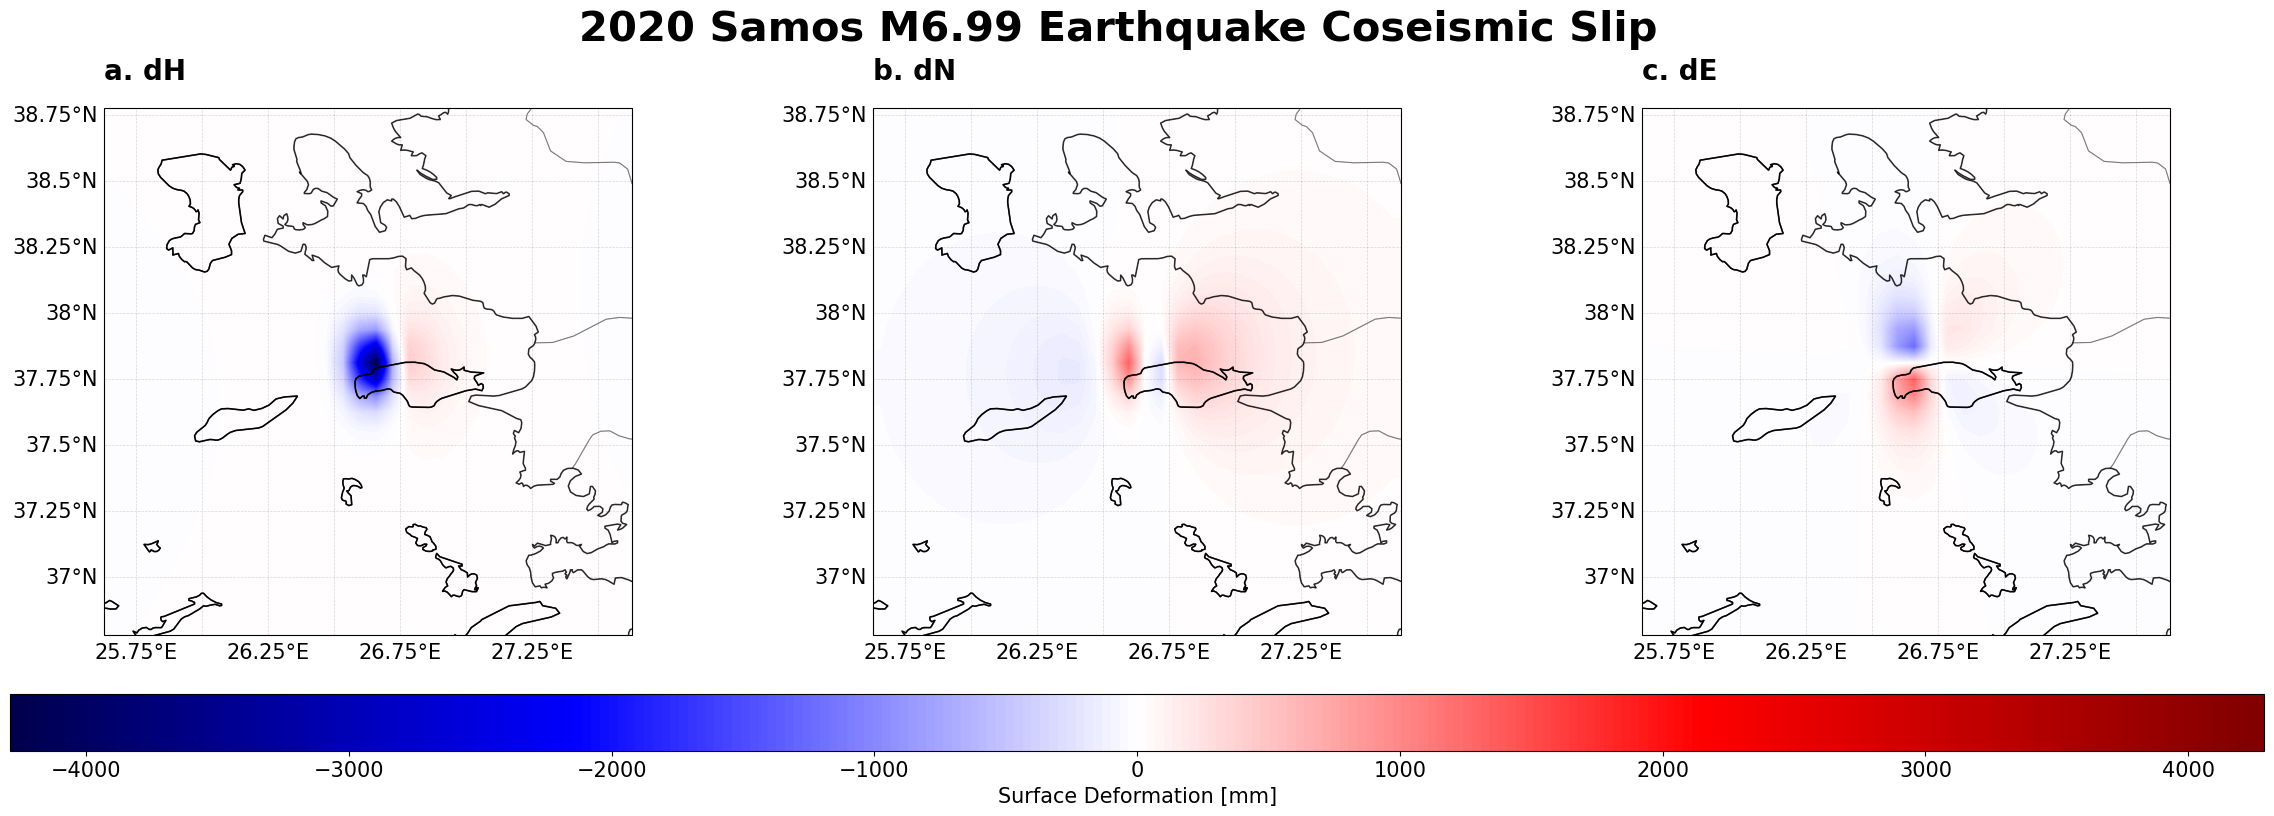

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(23, 8), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

Contour_data = ((Z_dH1, Z_dN1, Z_dE1))
Label_list = ((f'a. dH', f'b. dN', f'c. dE'))

for j in range (3):
    # Map Boundaries
    axs[j].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Surface Displacement Contour Plot
    im = axs[j].imshow(Contour_data[j], interpolation='bilinear', cmap="seismic",
                   origin='lower', extent=[lon_min, lon_max, lat_min, lat_max],
                   vmax=abs(Z).max(), vmin=-abs(Z).max())

    # Adding Features
    axs[j].add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2, edgecolor="black", alpha=0.6)
    axs[j].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black", facecolor="none", alpha=0.3)

    # Highlighting Greece using Natural Earth Country Shapefile
    shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
    reader = shpreader.Reader(shpfilename)
    countries = reader.records()
    for country in countries:
        name = country.attributes['SOVEREIGNT']
        if name == 'Greece':
            # Add Greece with your custom color
            axs[j].add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor="none", edgecolor='black', linewidth=1.0, zorder=2) #"orchid"
        else:
            # Add surrounding countries with a neutral background color
            axs[j].add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor="none", edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"

    # Gridlines
    gl = axs[j].gridlines(
        draw_labels=True, linewidth=0.5, color="black",
        alpha=0.15, linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"color": "black", "fontsize": 15}
    gl.ylabel_style = {"color": "black", "fontsize": 15}
    outline = [pe.withStroke(linewidth=2.5, foreground="black")]
    
    # Title
    axs[j].set_title(
        Label_list[j],
        fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
    )

# Colorbar
cbar = fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Surface Deformation [mm]', fontsize=15)

fig.suptitle( # Title
    "2020 Samos M6.99 Earthquake Coseismic Slip",
    fontsize=30, color="black", fontweight="bold"
)

plt.show()

/tmp/ipykernel_64452/140138343.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


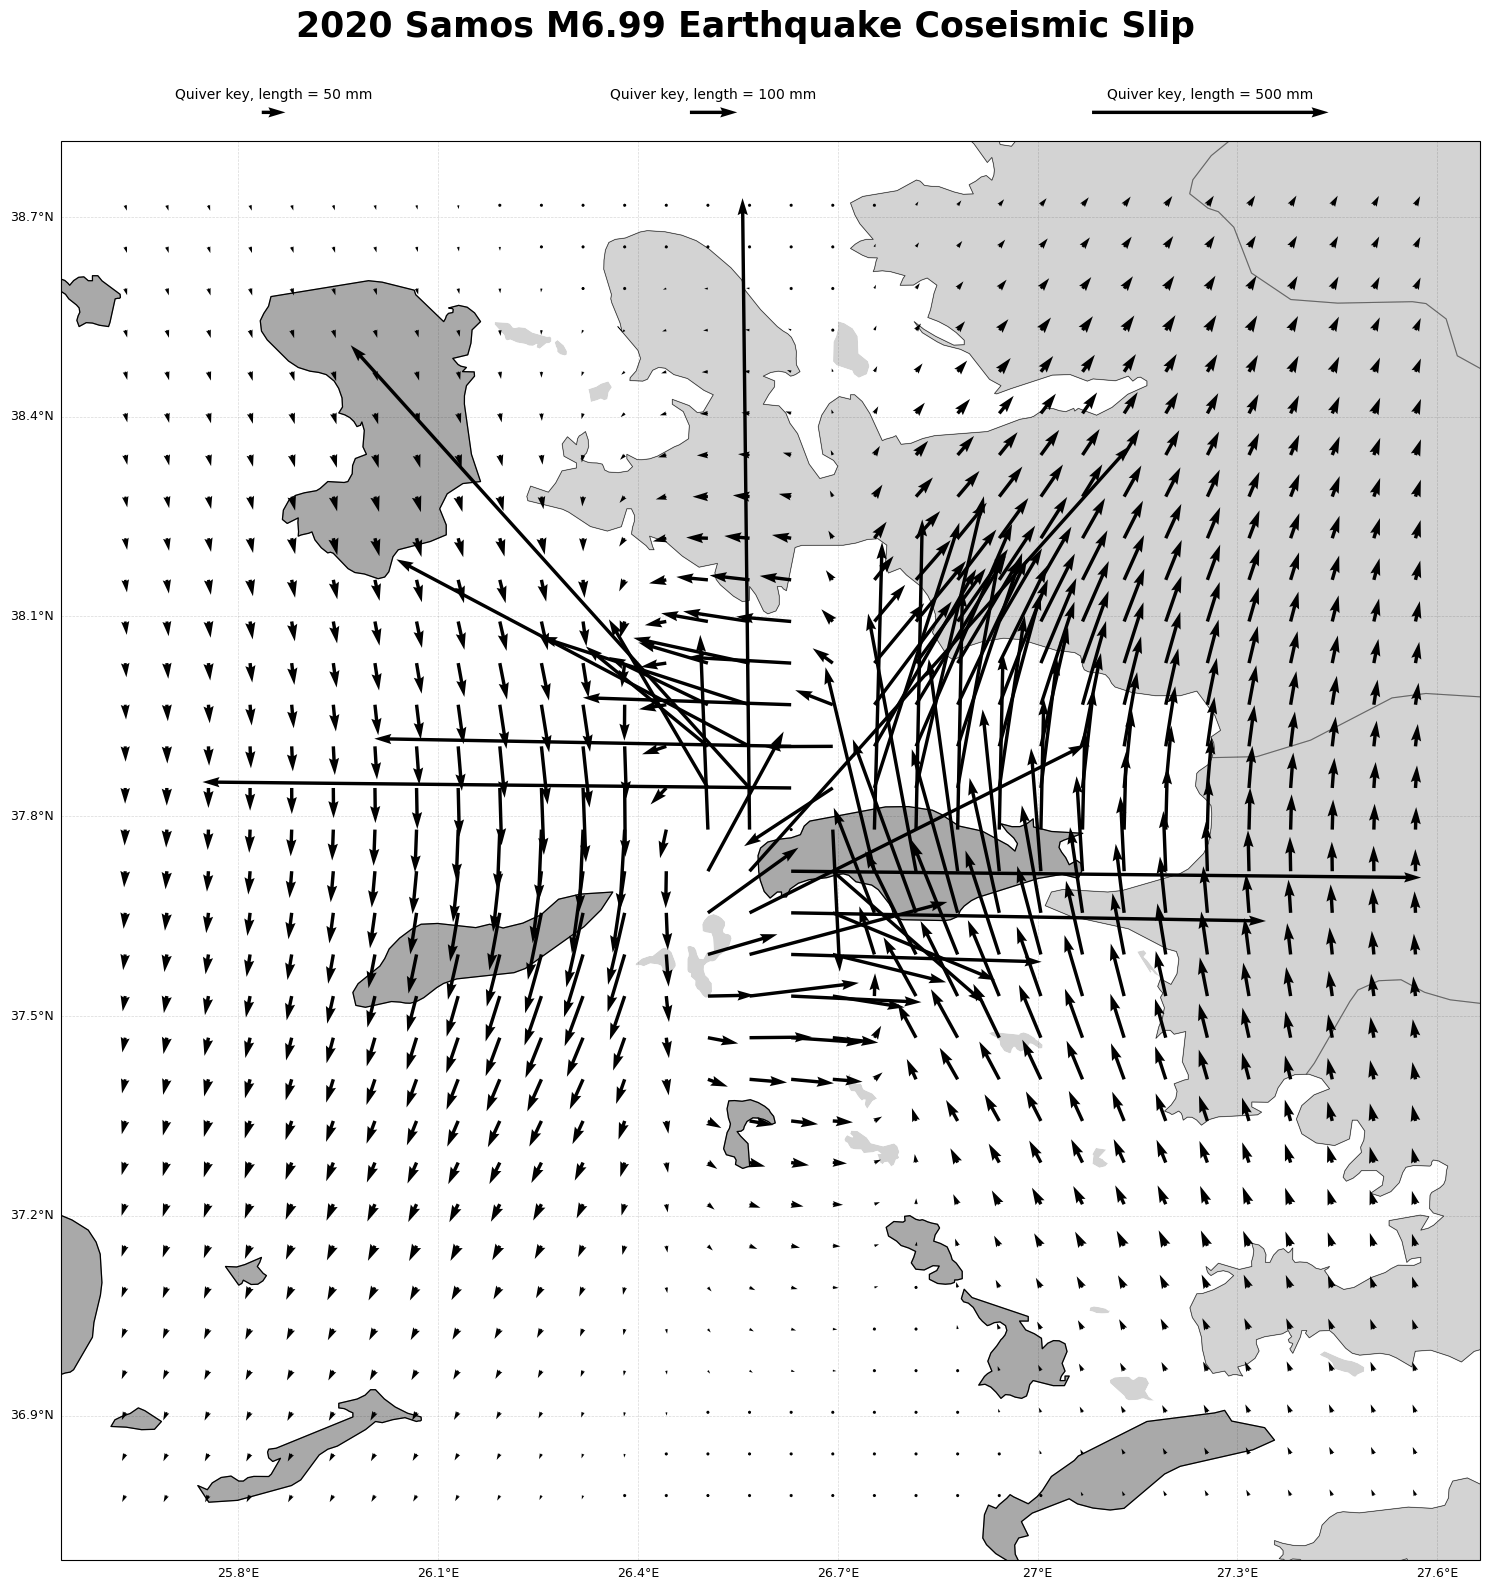

In [29]:
fig, ax = plt.subplots(figsize=(15, 17), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

Quiver_data = ((Z_dE1, Z_dN1))

# Surface Displacement Contour Plot
im = ax.quiver(X_mesh, Y_mesh, Quiver_data[0], Quiver_data[1], color='black', scale=3000, scale_units="width", zorder=4)
ax.quiverkey(im, X=0.15, Y=1.02, U=50, label='Quiver key, length = 50 mm', labelpos='N')
ax.quiverkey(im, X=0.46, Y=1.02, U=100, label='Quiver key, length = 100 mm', labelpos='N')
ax.quiverkey(im, X=0.81, Y=1.02, U=500, label='Quiver key, length = 500 mm', labelpos='N')

# Highlighting Greece using Natural Earth Country Shapefile
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shpfilename)
countries = reader.records()
for country in countries:
    name = country.attributes['SOVEREIGNT']
    if name == 'Greece':
        # Add Greece with your custom color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='darkgray', edgecolor='black', linewidth=0.9, zorder=2) #"orchid"
    else:
        # Add surrounding countries with a neutral background color
        ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                          facecolor='lightgray', edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"

# Adding Features
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black",
               facecolor="none", alpha=0.3, zorder=3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color="black",
    alpha=0.15, linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"color": "black", "fontsize": 9}
gl.ylabel_style = {"color": "black", "fontsize": 9}
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

# Title
fig.suptitle(
    "2020 Samos M6.99 Earthquake Coseismic Slip",
    fontsize=25, color="black", fontweight="bold"
)

plt.tight_layout()
plt.show()

## **2. Ten Largest Earthquakes in Greece from year 2000-2020** ##

In [32]:
# Catalog Data
big10_catalog = read_events("Big10_Greece_Seismicity.xml")

eq = 1
for event in big10_catalog:
    # Read earthquake data
    origin = event.preferred_origin() or event.origins[0]
    event_time = origin.time
    focal_mech = event.preferred_focal_mechanism() or event.focal_mechanisms[0]
    moment_tensor = focal_mech.moment_tensor
    nodal_planes = focal_mech.nodal_planes
    
    plane1 = nodal_planes.nodal_plane_1
    
    # Declare variables
    evlat = origin.latitude #degN
    evlon = origin.longitude #degE
    evdep = origin.depth #obspy automatically converts km to m
    
    strike1 = plane1.strike #deg
    dip1 = plane1.dip #deg
    rake1 = plane1.rake #deg
    
    mag = event.preferred_magnitude() or event.magnitudes[0]
    mag = float(mag.mag)
    m0 = moment_tensor.scalar_moment #obspy automatically converts from dyne-cm to N-m
    
    mu = 30.0 #GPa #mu
    lam = 30.0 #GPa #lambda

    # Creating Grid
    lon_min, lon_max = evlon-1.0, evlon+1.0
    lat_min, lat_max = evlat-1.0, evlat+1.0
    X = np.arange(lon_min, lon_max, 0.0625)
    Y = np.arange(lat_min, lat_max, 0.0625)
    X_mesh, Y_mesh = np.meshgrid(X, Y)
    
    Z_dE1 = np.zeros((len(X), len(Y)))
    Z_dN1 = np.zeros((len(X), len(Y)))
    Z_dH1 = np.zeros((len(X), len(Y)))

    for i in range(len(X)):
        for j in range(len(Y)):
            # Nodal plane 1
            ux, uy, uz = displacement (X[i], Y[j], evlon, evlat, evdep, strike1, dip1, rake1, m0, mu, lam)
            dN, dE, dH = NE_rotate(ux, uy, uz, strike1)
            # Computing Z deformation (dH)
            Z_dE1[i,j] = Z_dE1[i,j]+dE
            Z_dN1[i,j] = Z_dN1[i,j]+dN
            Z_dH1[i,j] = Z_dH1[i,j]+dH
    
    Z = np.array((np.max(abs(Z_dE1)), np.max(abs(Z_dN1)), np.max(abs(Z_dH1))))

    fig, axs = plt.subplots(1, 3, figsize=(23, 8), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    
    Contour_data = ((Z_dH1, Z_dN1, Z_dE1))
    Label_list = ((f'a. dH', f'b. dN', f'c. dE'))
    
    for j in range (3):
        # Map Boundaries
        axs[j].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # Surface Displacement Contour Plot
        im = axs[j].imshow(Contour_data[j], interpolation='bilinear', cmap="seismic",
                       origin='lower', extent=[lon_min, lon_max, lat_min, lat_max],
                       vmax=abs(Z).max(), vmin=-abs(Z).max())

        # Adding Features
        axs[j].add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2, edgecolor="black", alpha=0.6)
        axs[j].add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black", facecolor="none", alpha=0.3)

        # Highlighting Greece using Natural Earth Country Shapefile
        shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
        reader = shpreader.Reader(shpfilename)
        countries = reader.records()
        for country in countries:
            name = country.attributes['SOVEREIGNT']
            if name == 'Greece':
                # Add Greece with your custom color
                axs[j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor="none", edgecolor='black', linewidth=1.0, zorder=2) #"orchid"
            else:
                # Add surrounding countries with a neutral background color
                axs[j].add_geometries([country.geometry], ccrs.PlateCarree(),
                                  facecolor="none", edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"

        # Gridlines
        gl = axs[j].gridlines(
            draw_labels=True, linewidth=0.5, color="black",
            alpha=0.15, linestyle="--",
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"color": "black", "fontsize": 15}
        gl.ylabel_style = {"color": "black", "fontsize": 15}
        outline = [pe.withStroke(linewidth=2.5, foreground="black")]
        
        # Title
        axs[j].set_title(
            Label_list[j],
            fontsize=20, color="black", pad=20, loc='left', fontweight="bold"
        )
    
    # Colorbar
    cbar = fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label('Surface Deformation [mm]', fontsize=15)
    
    fig.suptitle( # Title
        f"EQ{eq}: M{mag} {event_time} Okada-Modelled Coseismic Slip",
        fontsize=30, color="black", fontweight="bold"
    )
    
    plt.savefig(f"Coseismic/Point/EQ{eq}_M{mag}{event_time}_CoseismicSlip.png")
    plt.close()

# Quiver Plot
    fig, ax = plt.subplots(figsize=(15, 17), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')
    
    Quiver_data = ((Z_dE1, Z_dN1))

    # Surface Displacement Contour Plot
    im = ax.quiver(X_mesh, Y_mesh, Quiver_data[0], Quiver_data[1], color='black', scale=1250, scale_units="width", zorder=4)
    ax.quiverkey(im, X=0.06, Y=1.02, U=10, label='Quiver key, length = 10 mm', labelpos='E')
    ax.quiverkey(im, X=0.41, Y=1.02, U=50, label='Quiver key, length = 50 mm', labelpos='E')
    ax.quiverkey(im, X=0.76, Y=1.02, U=100, label='Quiver key, length = 100 mm', labelpos='E')
    
    # Highlighting Greece using Natural Earth Country Shapefile
    shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
    reader = shpreader.Reader(shpfilename)
    countries = reader.records()
    for country in countries:
        name = country.attributes['SOVEREIGNT']
        if name == 'Greece':
            # Add Greece with your custom color
            ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor='darkgray', edgecolor='black', linewidth=0.9, zorder=2) #"orchid"
        else:
            # Add surrounding countries with a neutral background color
            ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                              facecolor='lightgray', edgecolor='black', linewidth=0.3, zorder=1) #"powderblue"
    
    # Adding Features
    ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="lightgrey", edgecolor="none")
    ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="white", edgecolor="none")
    ax.add_feature(cfeature.STATES.with_scale("10m"), linewidth=0.8, edgecolor="black",
                   facecolor="none", alpha=0.3, zorder=3)
    
    # Gridlines
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5, color="black",
        alpha=0.15, linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"color": "black", "fontsize": 9}
    gl.ylabel_style = {"color": "black", "fontsize": 9}
    outline = [pe.withStroke(linewidth=2.5, foreground="black")]
        
    fig.suptitle(
        f"EQ{eq}: M{mag} {event_time} Okada-Modelled Coseismic Slip",
        fontsize=25, color="black", fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(f"Coseismic/Point/EQ{eq}_M{mag}{event_time}_CoseismicSlip_2DQuiver.png")
    plt.close()
    
    eq = eq+1

/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_64452/1147392874.py:165: UserWarning: The figure layout has changed to tight
  pl